In [1]:
import yaml
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Configuration and paths
mac = 20
pheno_list_type = None
# pheno_list_type = 'biochemistry'
# pheno_list_type = 'overall_phenotype'

# Load phenotype configuration
pheno_config_path = "/home/dnanexus/ukbgym/phenotype_config.yaml"
with open(pheno_config_path) as f:
    pheno_config = yaml.safe_load(f)

if pheno_list_type is not None:
    pheno_list = pheno_config[pheno_list_type]

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_wgs.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#E31A1C""","""LOFTEE HC""",1
"""plof_consequences""","""consequence_frameshift_variant""","""#E31A1C""","""VEP Frameshift""",1
"""plof_consequences""","""consequence_stop_gained""","""#FB9A99""","""VEP Stop Gained""",1
"""plof_consequences""","""consequence_splice_donor_varia…","""#6A1B9A""","""VEP Splice Donor""",1
"""plof_consequences""","""consequence_splice_acceptor_va…","""#AB47BC""","""VEP Splice Acceptor""",1
…,…,…,…,…
"""vep_consequences""","""consequence_splice_acceptor_va…","""#AB47BC""","""VEP Splice Acceptor""",1
"""vep_consequences""","""consequence_start_lost""","""#E65100""","""VEP Start Lost""",1
"""vep_consequences""","""consequence_stop_lost""","""#FFB300""","""VEP Stop Lost""",1


In [3]:
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated/annotations_fillna_ukbgym.parquet -o /home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet

anno = pl.scan_parquet("/home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet")

min_range = -2000
max_range = +0

anno = (
    anno
    .filter(
        # Choose CDS
        (pl.col('vep_cds_relaxed')==True) &
        # ((pl.col('vep_cds_relaxed')==True) | (pl.col('mane_cds')==True)) &
        # (pl.col('non_mane_cds')==False) &

        # Choose non CDS only
        # ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)) &

        # Choose Gene Body
        # ((pl.col('consequence_upstream_gene_variant') == False) & (pl.col('consequence_downstream_gene_variant') == False)) &

        # Choose VEP consequence
        # (pl.col('consequence_missense_variant') == True) &
        # (pl.col('consequence_synonymous_variant') == True) &
        # (pl.col('consequence_5_prime_utr_variant') == True) &
        # (pl.col('consequence_upstream_gene_variant') == True) &
        # (pl.col('consequence_downstream_gene_variant') == True) &
        # (pl.col('consequence_intron_variant') == True) &

        # Choose MobiDB region
        # (pl.col('mobi_lip_full') == True) &
        # (pl.col('mobi_disorder_full') == True) &

        # Custom variant class filter
        # (pl.col('relative_cds_position')>=0.5) &

        # Choose regulatory region
        # (pl.col('encode_eh_pr') == True) &
        # (pl.col('encode_all_tf') == True) &
        
        # Proximity to TSS
        # (pl.col('dist_to_tss') >= min_range) &
        # (pl.col('dist_to_tss') <= max_range) &

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    # .with_columns(
    #     core_promoter = pl.col('dist_to_tss').abs() <= 50,
    #     encode_annotated = pl.col('not_in_encode') == False,
    #     encode_eh_pr = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pls', 'encode_pels', 'encode_dels']),
    #     encode_all_tf = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_tf', 'encode_ca_tf']),
    # )
    .with_columns(
        loftee_disorder = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'mobi_curated_disorder_priority']),
        loftee_lip = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'mobi_lip_full']),
        loftee_ted = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'ted_domain']),
        loftee_low_complexity = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'low_complexity_domain']),
    )
)

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

anno = (
    anno
    .select(
        # set(['id', 'region', 'tss', 'strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
        set(['id', 'region']).union(set(existing_annos))
    )
    .collect(engine='streaming')
)

anno

Error: path "/home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet"
already exists but -f/--overwrite was not set


loftee_lip,cadd_raw,five_prime_utr_variant_consequence_ustop_lost,delta_score,consequence_missense_variant,low_complexity_domain,five_prime_utr_variant_consequence_uaug_lost,consequence_start_lost,loftee_disorder,esmscoremissense,gpn_score,verphylop,mobi_lip_full,ted_domain,absplice_dna_max,consequence_splice_donor_variant,id,five_prime_utr_variant_consequence_ustop_gained,loftee_low_complexity,consequence_synonymous_variant,consequence_stop_gained,consequence_frameshift_variant,mobi_curated_disorder_priority,loftee_lc,promoterai,abexp_abs_max,loftee_ted,five_prime_utr_variant_consequence_uaug_gained,region,score_pai3d,pangolin_score,absplice2_max,consequence_stop_lost,loftee_hc,consequence_splice_acceptor_variant,am_pathogenicity
bool,f32,u8,f32,i8,bool,u8,i8,bool,f32,f32,f32,bool,bool,f32,i8,str,u8,bool,i8,i8,i8,bool,i8,f32,f32,bool,u8,str,f32,f32,f32,i8,i8,i8,f32
false,3.681756,0,0.05,1,false,0,0,false,-4.246,-11.54,8.687,false,false,0.003,0,"""chr5:87376465:A:T""",0,false,0,0,0,false,0,0.0,0.060269,false,0,"""ENSG00000145715""",0.699444,0.03,0.000327,0,0,0,0.2063
true,7.69086,0,0.0,0,false,0,0,false,0.0,-1.6,2.372,true,false,0.003,0,"""chr1:177933615:G:A""",0,false,0,1,0,false,0,0.0,0.946601,false,0,"""ENSG00000120341""",0.0,0.06,0.002165,0,1,0,0.0
false,0.528766,0,0.0,0,false,0,0,false,0.0,0.36,-1.5,false,false,0.001,0,"""chr2:96816550:C:T""",0,false,1,0,0,false,0,-0.143,0.012463,false,0,"""ENSG00000168763""",0.0,0.0,0.000033,0,0,0,0.0
false,3.032575,0,0.08,1,false,0,0,false,-6.253,-8.09,6.948,true,false,0.0,0,"""chr2:178598858:G:A""",0,false,0,0,0,false,0,0.0,0.015385,false,0,"""ENSG00000155657""",0.0,0.03,0.000034,0,0,0,0.0
false,4.428444,0,0.0,1,false,0,0,false,-5.721,-5.12,-0.102,false,true,0.003,0,"""chr2:128318064:C:T""",0,false,0,0,0,false,0,0.0,0.160049,false,0,"""ENSG00000136720""",0.550982,0.0,0.000321,0,0,0,0.2002
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
false,5.248261,0,0.01,0,false,0,0,false,0.0,-6.74,-0.6,false,true,0.003,0,"""chr4:15816634:C:A""",0,false,0,1,0,false,0,0.0032,1.39091,true,0,"""ENSG00000004468""",0.0,0.03,0.002172,0,1,0,0.0
false,1.2186,0,0.0,0,true,0,0,false,0.0,-4.14,0.709,false,false,0.001,0,"""chr15:78077599:C:A""",0,false,1,0,0,false,0,-0.0234,0.013111,false,0,"""ENSG00000167202""",0.0,0.0,0.000033,0,0,0,0.0
false,0.213689,0,0.0,0,false,0,0,false,0.0,-0.88,2.934,true,true,0.001,0,"""chr14:67783209:G:A""",0,false,1,0,0,false,0,0.0,0.006189,false,0,"""ENSG00000072121""",0.0,0.0,0.000033,0,0,0,0.0


In [4]:
selected_annos = anno_config_df.filter(
    # pl.col('category').is_in(['vep_consequences']) # VEP CDS consequences
    # pl.col('category').is_in(['plof_consequences']) # VEP plof consequences
    # (pl.col('category').is_in(['plof', 'missense', 'genetic_diversity', 'conservation', 'splicing', 'regulatory_nondir'])) # CDS
    # (pl.col('category').is_in(['missense', 'genetic_diversity', 'conservation'])) # missense
    # (pl.col('category').is_in(['protein_domains'])) # protein domains
    (pl.col('category').is_in(['loftee_protein_domains'])) # protein domains
    # (pl.col('category').is_in(['splicing', 'genetic_diversity', 'conservation'])) # synonymous

    # (pl.col('category').is_in(['splicing', 'conservation', 'regulatory_nondir', 'genetic_diversity'])) # non coding
    # (pl.col('category').is_in(['encode_regions'])) # encode regions
    # (pl.col('category').is_in(['encode_custom'])) # encode regions custom
    # (pl.col('category').is_in(['conservation', 'regulatory_nondir', 'genetic_diversity'])) # 5UTR
)['annotation'].to_list()

# # Load fillna annotations
# anno_fillna = pl.scan_parquet("/home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet")
# fillna_cols = set([c+'_is_na' for c in existing_annos]).intersection(set(anno_fillna.collect_schema().names()))

# anno_fillna_melted = (
#     anno_fillna
#     .select(['id', 'region'] + list(fillna_cols))
#     .join(
#         anno.select(['id', 'region']).lazy(), 
#         on=['id', 'region'], 
#         how='semi'
#     )
#     .unpivot(
#         index=["id", "region"],
#         on=list(fillna_cols),
#         variable_name="annotation",
#         value_name="annotation_is_na"
#     )
#     .filter(
#         pl.col('annotation_is_na') == False
#     )
#     .with_columns(
#         annotation = pl.col('annotation').str.replace('_is_na$', '')
#     )
#     # .collect(engine='streaming')
# )

melted_anno = (
    anno.lazy()

    .select(
        set(['id', 'region']).union(set(selected_annos))
    )

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )
    
    # Keep variants that don't have fillna annotation
    # .join(
    #     anno_fillna_melted,
    #     on=['id', 'region', 'annotation'],
    #     how='semi'
    # )
    .collect(engine='streaming')
)

melted_anno

id,region,annotation,annotation_score
str,str,str,f32
"""chr5:87376465:A:T""","""ENSG00000145715""","""loftee_disorder""",0.0
"""chr1:177933615:G:A""","""ENSG00000120341""","""loftee_disorder""",0.0
"""chr2:96816550:C:T""","""ENSG00000168763""","""loftee_disorder""",0.0
"""chr2:178598858:G:A""","""ENSG00000155657""","""loftee_disorder""",0.0
"""chr2:128318064:C:T""","""ENSG00000136720""","""loftee_disorder""",0.0
…,…,…,…
"""chr4:15816634:C:A""","""ENSG00000004468""","""loftee_low_complexity""",0.0
"""chr15:78077599:C:A""","""ENSG00000167202""","""loftee_low_complexity""",0.0
"""chr14:67783209:G:A""","""ENSG00000072121""","""loftee_low_complexity""",0.0


In [5]:
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var/loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet -o /home/dnanexus/data_dir/loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet

appv = pl.scan_parquet("/home/dnanexus/data_dir/loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)
# unique_phenotypes = appv.select('phenotype').unique().collect(engine='streaming').to_series()

Error: path "/home/dnanexus/data_dir/loftee_mac20_quant_pheno_assocs_EURunrela
ted_appv_percentiles.parquet" already exists but -f/--overwrite was not set


In [6]:
# Get gene trait associations
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/regenie_127phenotypes_lofteeHC_mac20_EUR.parquet -o /home/dnanexus/data_dir/
# !dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/loftee_mac20_associations_bh_corrected.parquet -o /home/dnanexus/data_dir/

!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet -o /home/dnanexus/data_dir/

gene_trait_df = (
    pl.read_parquet('/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR.parquet')
    .filter(pl.col('pval_fdr')<=0.05)
    .select(['region', 'phenotype', 'pval_fdr'])
)

loftee_corrs = (
    pl.read_parquet('/home/dnanexus/data_dir/regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

gene_trait_df = (
    gene_trait_df
    .join(loftee_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    # .sort('loftee_corr_abs', descending=True)
    # .sort('pval_fdr')
    # .unique(subset=["region"], keep="first", maintain_order=True)
)
gene_trait_df

Error: path
"/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR.parquet"
already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_mac20_lofteeHC_EUR_
correlations.parquet" already exists but -f/--overwrite was not set


region,phenotype,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64,f64
"""ENSG00000067900""","""lymphocyte_count_int""",0.015659,-0.097882,0.097882,-1.0
"""ENSG00000145386""","""mean_corpuscular_haemoglobin_i…",0.000096,-0.059845,0.059845,-1.0
"""ENSG00000164944""","""trunk_predicted_mass_int""",0.015511,-0.04623,0.04623,-1.0
"""ENSG00000107863""","""trunk_predicted_mass_int""",0.033889,-0.122605,0.122605,-1.0
"""ENSG00000121966""","""eosinophill_percentage_int""",0.000392,-0.075765,0.075765,-1.0
…,…,…,…,…,…
"""ENSG00000142208""","""arm_predicted_mass_right_int""",0.009537,-0.049973,0.049973,-1.0
"""ENSG00000101670""","""cholesterol_int""",0.000099,0.035791,0.035791,1.0
"""ENSG00000017427""","""weight_int""",0.000158,-0.170599,0.170599,-1.0


In [7]:
# --- 1. Lazily prepare the filter keys ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = melted_anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())


# --- 2. Build the main lazy query plan step-by-step ---
# Start by filtering 'appv', then join everything together. Every operation returns another LazyFrame.
final_lazy_plan = (
    # A. Use a semi join for efficient filtering (more memory-safe than 'is_in')
    appv
    .join(anno_ids_lazy, on="id", how="semi")

    # B. Join the other two dataframes
    .join(
        melted_anno.lazy().drop([c for c in melted_anno.columns if 'is_nan' in c]),
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df["region", "phenotype"].lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )

    # C. Apply the ranking (window function) lazily
    .with_columns(
        pl.col(c)
        .rank("average")
        .over(["region", "phenotype", "annotation"])
        .alias(f"{c}_rank")
        for c in ['annotation_score', 'mean_pheno_value']
    )

    # D. Apply the group_by and aggregation lazily
    # .group_by(["region", "gene_name", "phenotype", "annotation"])
    .group_by(["region", "phenotype", "annotation"])
    .agg(
        n_variants = pl.col("id").count(),
        correlation = pl.corr("annotation_score_rank", "mean_pheno_value_rank", propagate_nans=True)
    )
)

# --- 3. Execute the ENTIRE plan at once ---
# This is the ONLY time data is computed. The streaming engine handles the whole complex query in memory-safe chunks.
print("Executing the full lazy plan with the streaming engine...")
correlation_df = final_lazy_plan.collect(engine='streaming')
correlation_df

Executing the full lazy plan with the streaming engine...


region,phenotype,annotation,n_variants,correlation
str,str,str,u64,f64
"""ENSG00000119707""","""arm_fatfree_mass_right_int""","""loftee_ted""",495,NaN
"""ENSG00000110076""","""leg_fat_percentage_right_int""","""loftee_low_complexity""",1406,NaN
"""ENSG00000169047""","""leg_fatfree_mass_right_int""","""loftee_lip""",925,-0.054257
"""ENSG00000138688""","""weight_int""","""loftee_ted""",2893,NaN
"""ENSG00000127585""","""leg_fat_percentage_left_int""","""loftee_ted""",248,NaN
…,…,…,…,…
"""ENSG00000178252""","""whole_body_fatfree_mass_int""","""loftee_low_complexity""",790,-0.033797
"""ENSG00000130226""","""diastolic_blood_pressure_autom…","""loftee_ted""",772,-0.006543
"""ENSG00000107625""","""arm_fatfree_mass_right_int""","""loftee_low_complexity""",486,-0.012452


In [8]:
# --- 4. Join with beta directions and annotation directions ---
correlation_df = (
    correlation_df
    .filter(pl.col('annotation')!='loftee_hc')
    .select(["region", "phenotype", "annotation", "n_variants", "correlation"])
    .join(
        anno_config_df.drop('category').unique(), 
        on='annotation'
    )
    .join(
        gene_trait_df,
        on=['region', 'phenotype'],
    )
    .with_columns(
        corr_beta = pl.col('correlation')*pl.col('loftee_corr_dir')*pl.col('annotation_dir') 
    )
    .with_columns(
        corr_beta_rescaled = (pl.col('corr_beta')/pl.col('loftee_corr'))*pl.col('loftee_corr_dir')
    )
    .drop_nans()
)
print("Final DataFrame shape:", correlation_df.shape)
correlation_df

Final DataFrame shape: (4510, 14)


region,phenotype,annotation,n_variants,correlation,color,label,annotation_dir,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir,corr_beta,corr_beta_rescaled
str,str,str,u64,f64,str,str,i8,f64,f64,f64,f64,f64,f64
"""ENSG00000169047""","""leg_fatfree_mass_right_int""","""loftee_lip""",925,-0.054257,"""#1E90FF""","""LIP domain""",1,0.004833,-0.071383,0.071383,-1.0,0.054257,0.760083
"""ENSG00000100697""","""trunk_fatfree_mass_int""","""loftee_disorder""",1090,0.023354,"""#E31A1C""","""Disordered domain""",1,0.041062,0.06834,0.06834,1.0,0.023354,0.341733
"""ENSG00000137198""","""mean_corpuscular_haemoglobin_i…","""loftee_ted""",278,0.030228,"""#2E8B57""","""Structured Domain""",1,0.037236,0.084252,0.084252,1.0,0.030228,0.358785
"""ENSG00000258366""","""diastolic_blood_pressure_autom…","""loftee_ted""",2195,-0.035593,"""#2E8B57""","""Structured Domain""",1,0.037226,-0.06059,0.06059,-1.0,0.035593,0.587433
"""ENSG00000004939""","""direct_bilirubin_int""","""loftee_lip""",633,0.03158,"""#1E90FF""","""LIP domain""",1,1.2081e-21,0.18145,0.18145,1.0,0.03158,0.174042
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000178252""","""whole_body_fatfree_mass_int""","""loftee_low_complexity""",790,-0.033797,"""#FF9933""","""Low complexity domain""",1,0.00031,-0.078684,0.078684,-1.0,0.033797,0.429534
"""ENSG00000130226""","""diastolic_blood_pressure_autom…","""loftee_ted""",772,-0.006543,"""#2E8B57""","""Structured Domain""",1,0.044214,-0.068025,0.068025,-1.0,0.006543,0.096187
"""ENSG00000107625""","""arm_fatfree_mass_right_int""","""loftee_low_complexity""",486,-0.012452,"""#FF9933""","""Low complexity domain""",1,0.01651,0.083204,0.083204,1.0,-0.012452,-0.149658


In [9]:

consistent_gt = (
    correlation_df
    # .filter(pl.col('annotation')!='promoterai_abs')
    .drop_nulls().drop_nans()
    .group_by(['region', 'phenotype'])
    .agg(n_annotations = pl.len())
    .sort('n_annotations', descending=True)
    .filter(pl.col('n_annotations') == correlation_df['annotation'].n_unique())
)

# filt_corr_df = correlation_df.filter(pl.col("n_variants") > 10)  # Select genes with more than 10 variants
filt_corr_df = correlation_df.filter(pl.col("n_variants") > 100)
filt_corr_df = filt_corr_df.join(consistent_gt, on=['region', 'phenotype'], how='inner')
filt_corr_df

region,phenotype,annotation,n_variants,correlation,color,label,annotation_dir,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir,corr_beta,corr_beta_rescaled,n_annotations
str,str,str,u64,f64,str,str,i8,f64,f64,f64,f64,f64,f64,u64
"""ENSG00000169047""","""leg_fatfree_mass_right_int""","""loftee_lip""",925,-0.054257,"""#1E90FF""","""LIP domain""",1,0.004833,-0.071383,0.071383,-1.0,0.054257,0.760083,4
"""ENSG00000117139""","""igf1_int""","""loftee_lip""",1198,-0.040435,"""#1E90FF""","""LIP domain""",1,1.2013e-7,-0.117431,0.117431,-1.0,0.040435,0.344333,4
"""ENSG00000105610""","""mean_sphered_cell_volume_int""","""loftee_lip""",280,-0.094205,"""#1E90FF""","""LIP domain""",1,0.000004,-0.197859,0.197859,-1.0,0.094205,0.47612,4
"""ENSG00000178163""","""arm_fatfree_mass_left_int""","""loftee_ted""",738,-0.028615,"""#2E8B57""","""Structured Domain""",1,0.015392,0.014189,0.014189,1.0,-0.028615,-2.016781,4
"""ENSG00000159023""","""glycated_haemoglobin_hba1c_int""","""loftee_disorder""",568,-0.054199,"""#E31A1C""","""Disordered domain""",1,7.2807e-24,-0.180567,0.180567,-1.0,0.054199,0.30016,4
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000155657""","""arm_fatfree_mass_left_int""","""loftee_ted""",21987,0.00381,"""#2E8B57""","""Structured Domain""",1,1.8830e-16,-0.035144,0.035144,-1.0,-0.00381,-0.108418,4
"""ENSG00000187790""","""systolic_blood_pressure_automa…","""loftee_lip""",1273,-0.022394,"""#1E90FF""","""LIP domain""",1,0.024217,-0.060511,0.060511,-1.0,0.022394,0.37008,4
"""ENSG00000163554""","""mean_sphered_cell_volume_int""","""loftee_disorder""",1915,0.008632,"""#E31A1C""","""Disordered domain""",1,2.5619e-30,-0.167234,0.167234,-1.0,-0.008632,-0.051619,4


In [10]:
annos_w_inconsistent_assocs = (
    filt_corr_df
    .drop_nulls().drop_nans()
    .select(['region', 'phenotype', 'annotation'])
    .group_by('annotation')
    .agg(n_associations = pl.len())
    .select('n_associations').n_unique()
) - 1

print(f"Annotations with inconsistent associations: {annos_w_inconsistent_assocs}")

# Check if the variant counts are consistent within each (region, phenotype) pair
var_inconsistent = (
    filt_corr_df
    .drop_nans()
    .drop_nulls()
    .group_by(["region", "phenotype"])
    .agg(pl.col("n_variants").n_unique().alias("n_variants_unique"))
    .filter(pl.col("n_variants_unique") > 1)
)
print(f"Inconsistent (region, phenotype) pairs: {var_inconsistent.shape[0]}")

Annotations with inconsistent associations: 0
Inconsistent (region, phenotype) pairs: 0


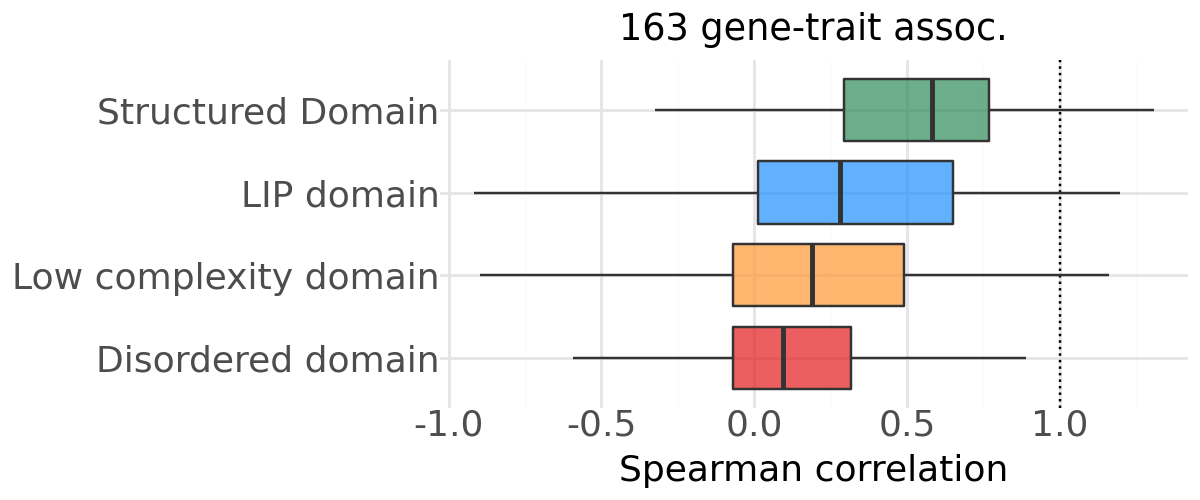

In [11]:
# Prepare for plotting
# plotting_col = 'corr_beta'
plotting_col = 'corr_beta_rescaled'

dashed_line_value = 1 if 'rescaled' in plotting_col else 0

med_df = filt_corr_df.drop_nans().group_by("annotation").agg(
    median_corr_beta = pl.col(plotting_col).median(),
)

corr_pd = med_df.join(filt_corr_df, on='annotation').to_pandas()

corr_pd['label'] = pd.Categorical(
    corr_pd['label'],
    categories=corr_pd.sort_values('median_corr_beta', ascending=True)['label'].unique(),
    ordered=True
)

color_dict = dict(zip(corr_pd['annotation'], corr_pd['color']))

# Plot
(
    ggplot(corr_pd, aes(x="label", y=plotting_col, fill="annotation"))
    + geom_hline(aes(yintercept=dashed_line_value), color='black', linetype='dotted')
    # + geom_boxplot(alpha=0.7)
    + geom_boxplot(alpha=0.7, outlier_shape=None)
    + theme_minimal()
    + scale_fill_manual(values=color_dict)
    + labs(
        x="",
        y="Spearman correlation",
        title=f"{corr_pd[['region', 'phenotype']].drop_duplicates().shape[0]} gene-trait assoc."
        # \nGene body ±5kb"
        # \n VEP CDS variants"
        # \n Disorder region missense variants"
        # \n{variant_class} variants"
        # \nTSS [{min_range}bp, {max_range}bp]"
    )
    + coord_flip()
    + theme(
        figure_size=(6, corr_pd['annotation'].nunique()/2 + 0.5),
        legend_position="none",
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [12]:
med_df.sort('median_corr_beta')

annotation,median_corr_beta
str,f64
"""loftee_disorder""",0.093084
"""loftee_low_complexity""",0.189756
"""loftee_lip""",0.282235
"""loftee_ted""",0.582871


In [13]:
import itertools
from scipy.stats import wilcoxon

annotations = filt_corr_df.select(pl.col("annotation")).unique().to_series().to_list()
pairs = list(itertools.combinations(annotations, 2))

results = []
for a, b in pairs:
    # Subset to same gene-trait pairs where both VSMs have values
    df_a = filt_corr_df.filter(pl.col("annotation") == a).select(["region", "phenotype", "corr_beta"])
    df_b = filt_corr_df.filter(pl.col("annotation") == b).select(["region", "phenotype", "corr_beta"])

    merged = df_a.join(df_b, on=["region", "phenotype"], how="inner", suffix="_b")

    if merged.height > 0:
        stat, pval = wilcoxon(merged["corr_beta"].to_numpy(), merged["corr_beta_b"].to_numpy(), alternative="two-sided")
        results.append((a, b, merged.height, stat, pval))

# Make results dataframe
stats_df = pl.DataFrame(
    results,
    schema=["VSM_A", "VSM_B", "N_pairs", "W_stat", "pval_raw"]
)

stats_df.filter(pl.col("pval_raw") < 0.05).sort("pval_raw")
# stats_df.sort("pval_raw")

/tmp/ipykernel_711496/1012804157.py:20: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.


VSM_A,VSM_B,N_pairs,W_stat,pval_raw
str,str,i64,f64,f64
"""loftee_disorder""","""loftee_ted""",163,2085.0,2.5610e-14
"""loftee_ted""","""loftee_low_complexity""",163,2742.0,6.5708e-11
"""loftee_disorder""","""loftee_lip""",163,3707.0,8.1743e-7
"""loftee_ted""","""loftee_lip""",163,4008.0,0.000014
"""loftee_low_complexity""","""loftee_lip""",163,4907.0,0.003253
"""loftee_disorder""","""loftee_low_complexity""",163,5272.0,0.019388


In [14]:
stats_df.filter(
    (pl.col('VSM_A') == 'absplice2_max') | (pl.col('VSM_B') == 'absplice2_max')
)

VSM_A,VSM_B,N_pairs,W_stat,pval_raw
str,str,i64,f64,f64
